# Week 6: Regression Models and Regularisation

The dataset and part of the exercises for this week were taken from MLPA.

<hr style="border:2px solid gray">

## Index: <a id='index'></a>
1. [Linear Regression](#linear)
2. [Gradient Descent](#gradient)
3. [Regularisation](#regularisation)
4. [Logistic Regression](#logistic)
5. [Poisson Regression](#poisson)


<hr style="border:2px solid gray">

## Linear Regression: <a id='linear'></a>

Let's start with some of our standard imports:

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## New modules
from sklearn import linear_model 
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV, LassoCV 
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import PoissonRegressor

We begin by generating some data in the form of $y = 3x + 3$, and adding some noise. Note that the noise that we are adding is not Gaussian to show that we don't need our noise to be Gaussian for this to work.

In [3]:
np.random.seed(16) #set seed for reproducibility purposes

x = np.arange(100) 

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) #generate some data with scatter following Poisson distribution 
                                                    #with exp value = y from linear model, centered around 0

Text(0, 0.5, 'Y')

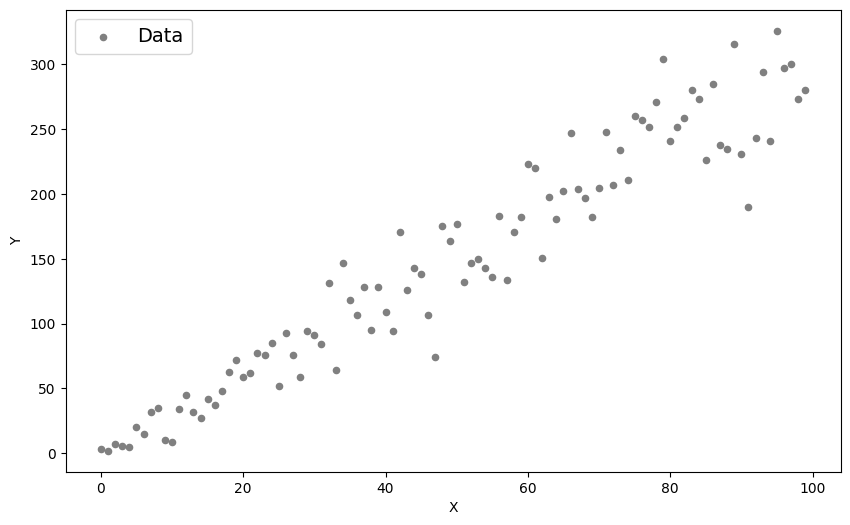

In [4]:
#Let's take a look!
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')


Now let's define the linear regression model: 

In [5]:
model = linear_model.LinearRegression()

In [6]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


I can fit the model (right now, I will do it using the entire data set just to compare with the analytic solution). When only one predictor is present, I need to reshape it to column form.

In [7]:
model.fit(x.reshape(-1,1),yp) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


If you are not sure why we needed the `reshape` method as well, print `x` and `x.reshape(-1,1)` to check the difference between the two arrays:

In [8]:
print(x)
print(x.reshape(-1,1))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
[[ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]
 [18]
 [19]
 [20]
 [21]
 [22]
 [23]
 [24]
 [25]
 [26]
 [27]
 [28]
 [29]
 [30]
 [31]
 [32]
 [33]
 [34]
 [35]
 [36]
 [37]
 [38]
 [39]
 [40]
 [41]
 [42]
 [43]
 [44]
 [45]
 [46]
 [47]
 [48]
 [49]
 [50]
 [51]
 [52]
 [53]
 [54]
 [55]
 [56]
 [57]
 [58]
 [59]
 [60]
 [61]
 [62]
 [63]
 [64]
 [65]
 [66]
 [67]
 [68]
 [69]
 [70]
 [71]
 [72]
 [73]
 [74]
 [75]
 [76]
 [77]
 [78]
 [79]
 [80]
 [81]
 [82]
 [83]
 [84]
 [85]
 [86]
 [87]
 [88]
 [89]
 [90]
 [91]
 [92]
 [93]
 [94]
 [95]
 [96]
 [97]
 [98]
 [99]]


The fitted model has attributes "coef_", "intercept_":

In [9]:
slope, intercept = model.coef_, model.intercept_

In [10]:
print(slope, intercept)

[3.02475848] -0.1255445544555016


<div style="background-color:#C2F5DD">

## Exercise 1
1. Plot the data in a scatter plot, overlaid with the fitted line and our original model line.
2. Calculate the the analytic predictions for the coefficients (using the formulae defined in the notes and in this week's presentation)
3. Now plot the residuals as a function of X. Comment on the shape of the graph.
4. Define a shuffled cross validation strategy with 5 folds and `random_state=10`, and print the test and train scores. What are the scores that are being printed out? Are they good/bad? Does it suffer from high variance? High bias? What would happen to the scores if we increased the scatter (noise)?
5. Repeat the same exercise as above but using the MSE and the MAE for scoring. (*Hint: you can find out all the available scorers by using `sklearn.metrics.get_scorer_names()`)*
6. Use the `metrics.make_scorer` function to define the *Modified Mean Absolute Percentage Error* and use it in your cross validation.
7. So far we have not changed the loss function (MSE), or the coefficients of the model. We have only looked at different evaluation metrics. Would the best fit line change if we optimise a different loss function? How can we implement that without an analytic solution?

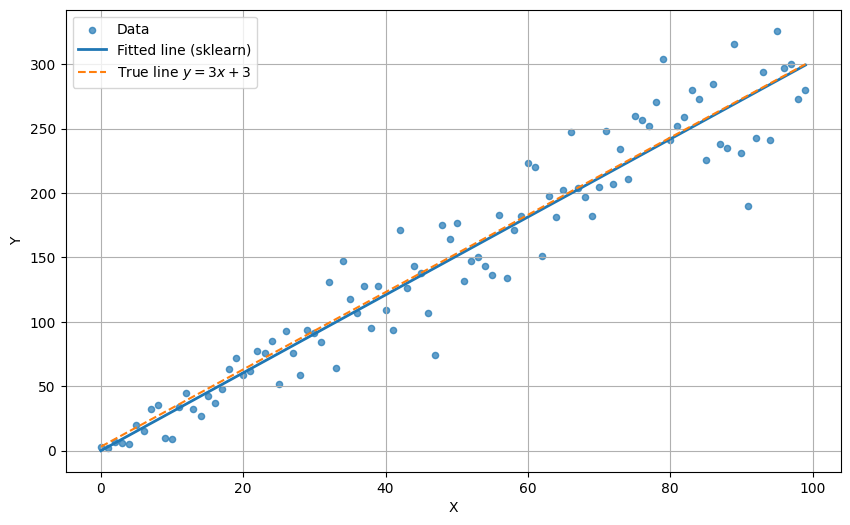

In [ ]:
# 1.
# Fitted line (from sklearn model)
y_fit = model.predict(x.reshape(-1, 1))

# Original underlying model: y = 3x + 3
y_true = 3 * x + 3

plt.figure(figsize=(10,6))
plt.scatter(x, yp, s=20, label='Data', alpha=0.7)
plt.plot(x, y_fit, label='Fitted line (sklearn)', linewidth=2)
plt.plot(x, y_true, label='True line $y = 3x+3$', linestyle='--')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
#2.
X_design = np.c_[np.ones((len(x),)), x]    # column of 1s + x
theta_analytic = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ yp)

intercept_analytic = theta_analytic[0]
slope_analytic = theta_analytic[1]
intercept_analytic, slope_analytic

(np.float64(-0.12554455445528445), np.float64(3.0247584758475834))

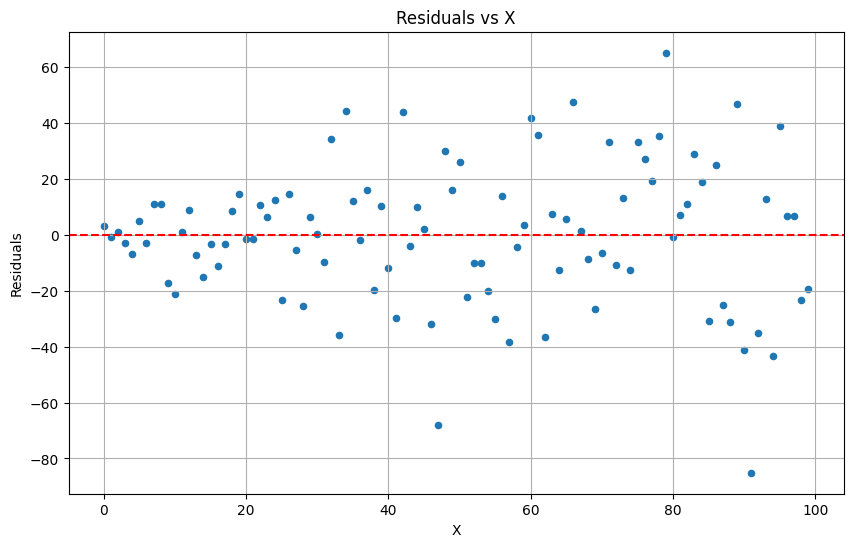

In [15]:
# 3.
y_pred = intercept_analytic + slope_analytic * x
residuals = yp - y_pred

plt.figure(figsize=(10,6))
plt.scatter(x, residuals, s=20)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("X")
plt.ylabel("Residuals")
plt.title("Residuals vs X")
plt.grid(True)
plt.show()

In [16]:
# 4.
from sklearn.model_selection import KFold, cross_validate

reg = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=10)

scores_r2 = cross_validate(reg,
                           x.reshape(-1, 1),
                           yp,
                           cv=cv,
                           scoring='r2',)

print("R² scores for each fold:", scores_r2['test_score'])
print("Mean R² score:", np.mean(scores_r2['test_score']))
print("Standard deviation of R² scores:", np.std(scores_r2['test_score']))

R² scores for each fold: [0.9165209  0.89174158 0.94218009 0.84836725 0.94721595]
Mean R² score: 0.9092051540796889
Standard deviation of R² scores: 0.03630954176706822


In [ ]:
# 5.
scores_mse = cross_validate(reg,
                           x.reshape(-1, 1),
                           yp,
                           cv=cv,
                           scoring='neg_mean_squared_error')

scores_mae = cross_validate(reg,
                           x.reshape(-1, 1),
                           yp,
                           cv=cv,
                           scoring='neg_mean_absolute_error')

mean_mse = -np.mean(scores_mse['test_score'])
std_mse = np.std(scores_mse['test_score'])

mean_mae = -np.mean(scores_mae['test_score'])
std_mae = np.std(scores_mae['test_score'])

print(f"Mean MSE: {mean_mse}, Std MSE: {std_mse}")
print(f"Mean MAE: {mean_mae}, Std MAE: {std_mae}")

Mean MSE: 668.7383104458291, Std MSE: 174.42242707664022
Mean MAE: 19.461305917082846, Std MAE: 1.9480405329485069


In [21]:
# 6.
from sklearn.metrics import make_scorer

def modified_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) /  np.maximum(np.abs(y_true), 1)))

mape_scorer = make_scorer(modified_mape, greater_is_better=False)

scores_mape = cross_validate(reg,
                            x.reshape(-1, 1),
                            yp,
                            cv=cv,
                            scoring=mape_scorer)

mean_mape = -np.mean(scores_mape['test_score'])
std_mape = np.std(scores_mape['test_score'])
print(f"Mean Modified MAPE: {mean_mape}, Std Modified MAPE: {std_mape}")

Mean Modified MAPE: 0.218312722817866, Std Modified MAPE: 0.04304720480914727


In [ ]:
# 7. Why different loss functions need different approach



### What happens when we add outliers?

In [22]:
np.random.seed(12) #set 
out = np.random.choice(100,15) #select 15 outliers indexes
yp_wo = np.copy(yp)
np.random.seed(12) #set again
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

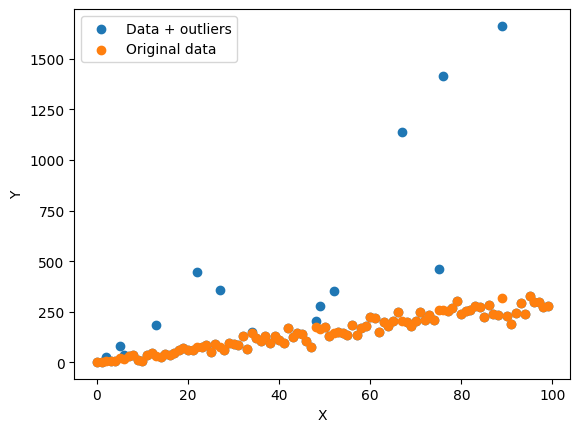

In [25]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend();

We can see the effect for the MSE loss right away:

In [26]:
model.fit(x.reshape(-1,1),yp_wo)

slope, intercept = model.coef_, model.intercept_

print(slope, intercept)

[3.97842184] 1.5481188118811815


These are the parameters obtained for the normal equation; we can save them to compare them to other methods.

In [27]:
theta_ne = np.array([[intercept],slope])

<hr style="border:2px solid gray">

## Gradient Descent: <a id='gradient'></a>

Let's now implement the simplest form of gradient descent: batch, stochastic, and mini-batch, one by one.

To begin with, we add x0 = 1 to each instance; this is the bias term and it is used in order to write the solution for a linear model in matrix multiplication form.

In [35]:
X = np.c_[np.ones((100, 1)), x]  

print(X.shape) #shape is number of instances x number of parameters


(100, 2)


We can calculate the loss associated with the normal equation like this:

$MSE=\dfrac{1}{N}|X \cdot \theta -y|^2$

Reminder that in our case $X$ is `X`, $\theta$ is vectors of parameters that we calculated using the normal equation (`theta_ne`), and $y$ is the version with outliers, `yp_wo.reshape(-1,1)`.

In [37]:
y = yp_wo.reshape(-1,1)
n_samples = X.shape[0]

loss_ne = (1/n_samples) * np.sum( np.abs( y - X @ theta_ne ) ** 2)

Print your result, you should get something of around 43260.

In [38]:
loss_ne

np.float64(43259.081624722465)

## The Gradient Descent:


**Implementation - MSE loss:**
The calculation of the gradients appearing in the gradient descent formulation is a key element in the optimisation. Modern software packages rely on algorithms to automatically and efficiently calculate gradients.
For the MSE loss, the gradient can be computed analytically.
We start from the generalised definition of the MSE, where $X$ is the features matrix and $\theta$ is parameters vector. Note that we add a bias term, a "fake" feature = 1, to every instance so that we can express the linear model as a matrix multiplication:

$$MSE=\dfrac{1}{N}|X \cdot \theta -y|^2$$

We can then get the gradient as:

$$\nabla_\theta MSE = \dfrac{2}{N} X^T (X \cdot \theta - y) $$

Advantages of gradient descent over normal equation for linear model:
 * No matrix inversion needed
 * Complexity scaling is now linear with $m$ (number of features), although it is not great with $N$ (number of samples) because we calculate the gradients by summing over the entire learning set.

#### Gradient Descent Variants 

Here's a breakdown of three common variations of gradient descent and the concept of a learning schedule:

**Batch Gradient Descent:**

This is the vanilla version of gradient descent. It considers the **entire** training dataset in each iteration to calculate the update for the model's parameters. 
The gradient is the average of the gradients of the cost function with respect to each parameter for all data points.

Advantages include that it guarantees to converge to a minimum (if the cost function is convex), and it can be more accurate than other variations due to considering all data.
However, it can be computationally expensive for large datasets, as calculations involve the entire dataset in each step.
   
**Stochastic Gradient Descent (SGD):**

This approach tackles the computational limitations of batch gradient descent. It updates the model parameters after processing **one individual data point** in the training set. 
The gradient is calculated based on a single data point at a time chosen randomly.

This is faster than batch gradient descent for large datasets due to its single data point updates and it can sometimes avoid getting stuck in local minima due to the randomness of the updates.
However, it can be noisy in its updates, leading to fluctuations in the cost function during convergence and we are not guaranteed to converge to a minimum.

**Mini-Batch Gradient Descent:**

This variant strikes a balance between batch gradient descent and stochastic gradient descent. It uses **small batches** of data points (mini-batches) to calculate the gradient and update the parameters. 
The gradient is the average of the gradients for each data point in the mini-batch.

It is faster than batch gradient descent, especially for large datasets, it is more stable updates than stochastic gradient descent due to averaging across a mini-batch, and often the preferred variant due to its balance between speed and stability.
Similarly to SGD, we are not guaranteed to converge to a minimum, and tuning the mini-batch size can be crucial for optimal performance.

**Learning Schedule:**

 The learning rate in gradient descent algorithms controls the step size taken in each iteration. A learning schedule defines how this learning rate changes over the course of the training process.
 A fixed learning rate might not be optimal. A high learning rate early on can help the model explore the cost function landscape quickly, while a lower learning rate later can allow for more precise convergence around the minimum.
Common Schedules include a fixed learning rate (simplest approach, but may not be optimal for all situations), a decaying learning rate (gradually reduces the learning rate over time), or an adaptive learning rates (adjust the learning rate based on specific conditions during training, e.g., AdaGrad, RMSprop).

**Summary of linear regression solvers:**

| Method | Large N | Large m | Hyper-parameters | Scaling | sklearn implementation |
|---|---|---|---|---|---|
| Normal Equation | slow | fast | - | no | `LinearRegressor` |
| Batch GD | fast | slow | yes | yes | - |
| Mini-Batch GD | fast | fast | yes | yes | - |
| Stochastic GD | fast | fast | yes | yes | `SGDRegressor` |

Note that the GD methods can all be used for other loss functions. The only difference is that the gradient computation is not analytical.

### Batch GD

<div style="background-color:#C2F5DD">

## Exercise 2
1. Fill in the code below to calculate the gradient descent using the batch gradient descent. Use the notes to help you filling in the gaps.
2. Print the values of $\theta$ found with the batch GD. These should be: 1.39 and 3.98. Calculate the loss function `loss_bgd` (which should be similar to the one above), and the percentage difference with the loss function from the normal equation `loss_ne`. 

In [41]:
np.random.seed(10) #same initial conditions for all

eta = 0.0001
n_iterations = 1000 #try changing this number!
n_samples = 100

theta_path_bgd = []

theta = np.random.randn(2,1)

for iteration in range(n_iterations):
    gradients = (2/n_samples) * X.T @ (X @ theta - y)
    theta = theta - eta * gradients
    theta_path_bgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd) #save the path

theta_bgd = theta #final result

In [44]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [47]:
loss_bgd = (1/n_samples) * np.sum( np.abs( y - X @ theta_bgd ) ** 2)

In [48]:
loss_bgd

np.float64(43259.08804185895)

In [46]:
diff_bgd = abs(loss_bgd - loss_ne) / loss_ne * 100
diff_bgd

np.float64(1.483419491479478e-05)

### Stochastic GD

<div style="background-color:#C2F5DD">

3. Complete the code below to calculate the stochastic GD.
4. Then print the values of $\theta$ found with the stochastic GD. These should be: 1.36 and 4.18. Calculate the loss function `loss_sgd`, and the percentage difference with the loss function from the normal equation `loss_ne`.

In [49]:
np.random.seed(10) #same initial conditions for all

theta = np.random.randn(2,1) 

eta = 0.000005

n_iterations = 10000 #more iterations are needed to get in the right ballpark!

theta_path_sgd = []

for epoch in range(n_iterations):
    
        random_index = np.random.randint(n_samples) # pick one example from the data 
        
        x_one = X[random_index:random_index+1]
        
        y_one = yp_wo[random_index:random_index+1]
        
        gradients = 2 * x_one.T @ (x_one @ theta - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)                 

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [50]:
theta_sgd

array([[1.3552955 ],
       [4.17721319]])

In [51]:
loss_sgd = (1/n_samples) * np.sum( np.abs( y - X @ theta_sgd ) ** 2)
loss_sgd

np.float64(43385.08132655123)

In [52]:
diff_sgd = abs(loss_sgd - loss_ne) / loss_ne * 100
diff_sgd

np.float64(0.29126763004779105)

### Mini batch GD

<div style="background-color:#C2F5DD">

5. Complete the code below to calculate the mini batch GD.
6. Then print the values of $\theta$ found with the mini batch GD. These should be: 1.38 and 4.26. Calculate the loss function `loss_mgd`, and the percentage difference with the loss function from the normal equation `loss_ne`.

In [53]:
np.random.seed(10)

theta = np.random.randn(2,1) 

eta = 0.000005

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10 #size of the mini batch

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(n_samples) #shuffle array 
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size] #select the first set from the shuffled array; equivalent to selecting a random subset
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = (2/minibatch_size) * xi.T @ (xi @ theta - yi)
    
    theta = theta - eta * gradients
    
    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta 

print(theta_mgd)

[[1.38191988]
 [4.25542902]]


In [57]:
loss_mgd = (1/n_samples) * np.sum( np.abs( y - X @ theta_mgd ) ** 2)
print(loss_mgd)

43506.50418469317


In [56]:
diff_mgd = abs(loss_mgd - loss_ne) / loss_ne * 100
print(diff_mgd)

0.5719551841556079


<div style="background-color:#C2F5DD">

7. Plot a scatter graph with the paths of $\theta_0$ on the x axis and $\theta_1$ on the y axis (you can use the arrays `theta_path_sgd/mgd/bgd` define above).
8. Add the final points found by the 3 methods.
*Ensure that your plot is readable and easily understanble (ie choose colours and markers appropriately, label axis and legends)*

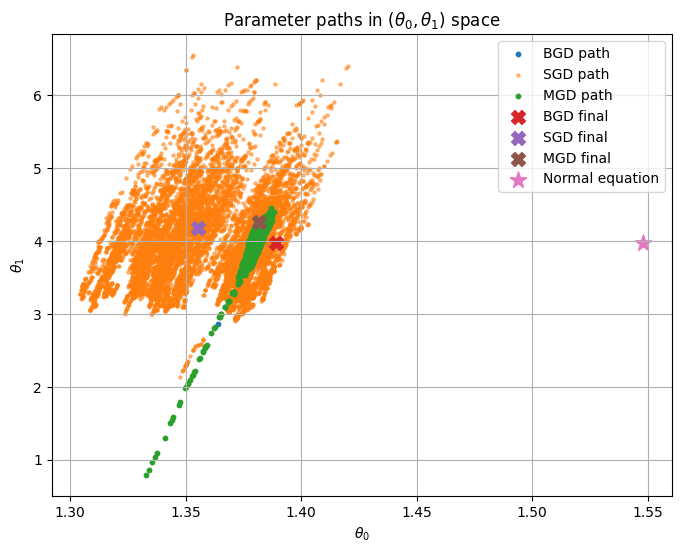

In [58]:
plt.figure(figsize=(8,6))
plt.scatter(theta_path_bgd[:,0,0], theta_path_bgd[:,1,0],
            s=10, label='BGD path')
plt.scatter(theta_path_sgd[:,0,0], theta_path_sgd[:,1,0],
            s=5, alpha=0.5, label='SGD path')
plt.scatter(theta_path_mgd[:,0,0], theta_path_mgd[:,1,0],
            s=10, label='MGD path')

# Final points
plt.scatter(theta_bgd[0,0], theta_bgd[1,0], marker='X', s=100, label='BGD final')
plt.scatter(theta_sgd[0,0], theta_sgd[1,0], marker='X', s=100, label='SGD final')
plt.scatter(theta_mgd[0,0], theta_mgd[1,0], marker='X', s=100, label='MGD final')
plt.scatter(theta_ne[0,0], theta_ne[1,0], marker='*', s=150, label='Normal equation')

plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title('Parameter paths in $(\\theta_0, \\theta_1)$ space')
plt.legend()
plt.grid(True)
plt.show()


<hr style="border:2px solid gray">

## Regularisation: <a id='regularisation'></a>


Regularisation is a technique used in machine learning, particularly in linear regression models, to address the issue of **overfitting**. Overfitting occurs when a model becomes too closely aligned with the training data, capturing noise and irrelevant details instead of the underlying generalisable patterns. This can lead to poor performance on unseen data.

**Regularisation Techniques:**

Regularisation introduces penalties to the loss function (e.g., mean squared error) used to train the model. These penalties discourage the model from having overly large coefficients (slopes) or complex structures. Here are two common regularisation techniques:

* **L2 Regularisation (Ridge Regression):**
    * This technique adds the square of each coefficient's magnitude to the loss function. Squaring the values penalises larger coefficients more heavily compared to L1. This encourages the model to shrink the coefficients towards zero but not necessarily eliminate them entirely. L2 regularisation often leads to a smoother, less complex model compared to the original unregularised model.
    * The modified loss function is: $loss=(X \cdot \theta - y)^2 + \alpha \sum_{i=1}^m \theta_i^2$
    * The larger $\alpha$ is, the stronger the regularisation (and the smaller the coefficients)
    * Analytic solution $\hat{\theta}_{RIDGE} = (X^T \cdot X + \alpha \cdot I)^{-1}X^T Y$

* **L1 Regularisation (LASSO Regression):**
    * This technique adds the absolute value of each coefficient's magnitude to the cost function. This penalty encourages the model to drive some coefficients towards zero, effectively removing them from the equation. This leads to a sparser model with fewer features, promoting simplicity and reducing overfitting.
    * The modified loss function is: $loss=(X \cdot \theta - y)^2 + \alpha \sum_{i=1}^m |\theta_i|$
    * When a feature $j$ is weak, $\theta_j$ is small, and this regularisation is stronger: in fact, it tends to set a bunch of coefficients to zero, making it great for feature selection.

The choice of regularisation technique and the strength of the penalty (controlled by a hyperparameter) depends on the specific problem and data characteristics. L1 regularisation is useful for feature selection, while L2 regularisation can improve model stability and generalisability.

Regularisation helps to improve the model's ability to generalise to unseen data by preventing it from becoming overly specific to the training data.
Regularisation can make the model less sensitive to small variations in the training data, leading to more consistent performance.


To compare the effects of adopting a linear model without regularisation, the Ridge Regression and the Lasso Regression, we are going to start by producing a multicollinear dataset.
We begin by generating a 3-feature sample (`xb`) following a linear relationship:

In [ ]:
np.random.seed(16) #set seed for reproducibility purposes

x1 = np.arange(100) 

x2 = np.linspace(0,1,100)

x3 = np.logspace(2,3,num=100) 

ypb = 3*x1 + 0.5*x2 + 15*x3 + 3 + 5*(np.random.poisson(3*x1 + 0.5*x2 + 15*x3,100)-(3*x1 + 0.5*x2 + 15*x3)) 
                                                    #generate some data with scatter following Poisson distribution 
                                                    #with exp value = y from linear model, centered around 0

In [ ]:
xb = np.vstack((x1,x2,x3)).T

In [ ]:
xb.shape

Now we create a new polynomial features from the original ones using `PolynomialFeatures`. This function generates a new feature matrix consisting of all polynomial combinations of the features with degree less than or equal to the specified degree. For example, if an input sample is two dimensional and of the form [a, b], the degree-2 polynomial features are [1, a, b, a^2, ab, b^2].

In [ ]:
poly = PolynomialFeatures(2, include_bias=False)

In [ ]:
new_xb = poly.fit_transform(xb)

In [ ]:
new_xb.shape

Let's start with Ridge regression, and tune alpha using cross-validation.


In [ ]:
MSE = []

for alpha in np.logspace(-6,6,13):

    model_reg = make_pipeline(StandardScaler(), Ridge(alpha = alpha, max_iter=10000)) 

    scores = cross_validate(model_reg, new_xb, ypb, cv = KFold(n_splits=5, shuffle=True, random_state = 1), scoring = 'neg_mean_squared_error')

    print(alpha, np.round(-np.mean(scores['test_score']))) #Note however that this only outputs the MSE
    
    MSE.append(-np.mean(scores['test_score']))

print('Best alpha:', np.logspace(-6,6,13)[np.argmin(MSE)])

We can also use a built-in function for this

In [ ]:
regm = make_pipeline(StandardScaler(with_mean=False),
                     RidgeCV(alphas=np.logspace(-6,6,13), \
            cv = KFold(n_splits=5, shuffle=True, random_state=1),\
             scoring = 'neg_mean_squared_error'))

regm.fit(new_xb,ypb); 

print('The best alpha is', regm[1].alpha_)



The line below gets the coefficients and intercept from the regularised model (these need to be rescaled as we applied the `StandardScaler` in our pipeline). Pay attention to how this line is written as you will need it in the next exercise.

In [ ]:
coef_alpha_10 = np.hstack([regm[1].intercept_, regm[1].coef_/regm[0].scale_])

print(coef_alpha_10)

<div style="background-color:#C2F5DD">

## Exercise 3
1. Calculate the intercept and coefficients for three cases: $\alpha=1000, 1, 1e-11$ (the last case is a shortcut for no regularisation). Comment on the results.
2. Make a bar chart to compare the values of the coefficients and intercept for the 4 cases. *Hints: use a y-log scale, and displace the bars by a small increment to visualise all of them.*
3. Comment on the results.
4. Now calculate the best alpha for the Lasso Regression using the `LassoCV` with `alphas = np.logspace(-1,4,6)` and `max_iter = 10000000` to allow convergence. What's the best alpha value?   
7. Calculate the intercept and coefficients for three cases: $\alpha=1000, 1, 1e-11$ (and keep using `max_iter = 1000000` to allow convergence). Comment on the results.
8. Make a bar chart to compare the values of the coefficients and intercept for the Ridge ($\alpha=1000, 1$), Lasso ($\alpha=1000, 1$), and no regularisation case. Comment on the results.